In [ ]:
# Step 1: Load dataset

import pandas as pd

df=pd.read_csv('../data/Mall_Customers.csv')
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [ ]:
# feature selection
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

In [ ]:
# STEP 2: Data scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
# STEP 3: Apply K-Means (Baseline Model)
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)
kmeans_labels = kmeans.fit_predict(X_scaled)

In [ ]:
# STEP 4: Apply GMM
from sklearn.mixture import GaussianMixture

gmm = GaussianMixture(n_components=3, random_state=42)
gmm.fit(X_scaled)

gmm_labels = gmm.predict(X_scaled)
gmm_probs = gmm.predict_proba(X_scaled)

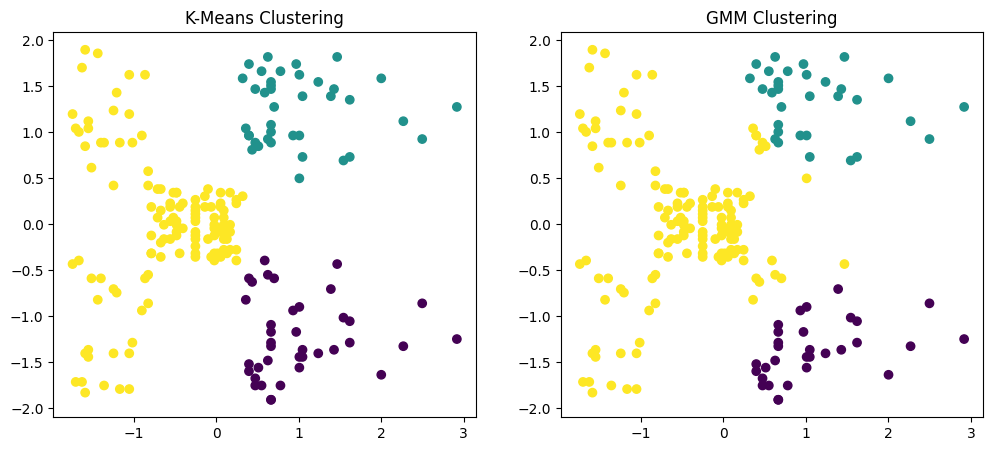

In [ ]:
# STEP 5: Visualization (Side-by-Side Comparison)
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

# K-Means
plt.subplot(1,2,1)
plt.scatter(X_scaled[:,0], X_scaled[:,1], c=kmeans_labels)
plt.title("K-Means Clustering")

# GMM
plt.subplot(1,2,2)
plt.scatter(X_scaled[:,0], X_scaled[:,1], c=gmm_labels)
plt.title("GMM Clustering")

plt.show()

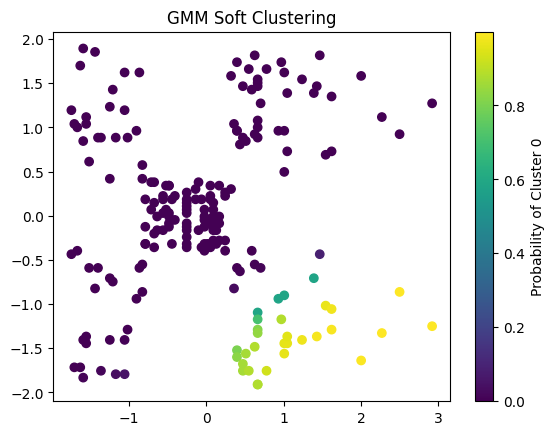

In [15]:
# STEP 6: Soft Clustering Visualization
plt.scatter(X_scaled[:,0], X_scaled[:,1], 
            c=gmm_probs[:,0], cmap='viridis')

plt.colorbar(label='Probability of Cluster 0')
plt.title("GMM Soft Clustering")

plt.show()

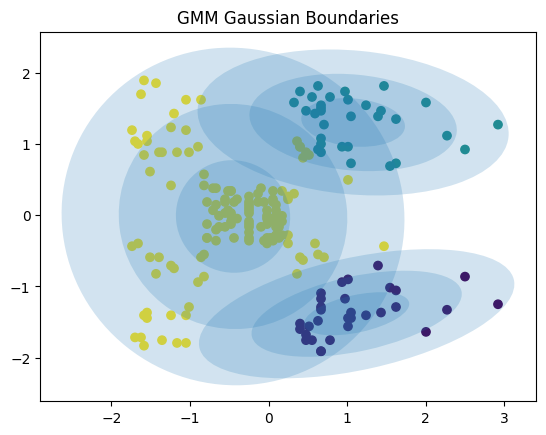

In [ ]:
# STEP 7: Add Elliptical Boundaries
import numpy as np
from matplotlib.patches import Ellipse

def draw_ellipse(position, covariance, ax=None):
    ax = ax or plt.gca()
    
    U, s, Vt = np.linalg.svd(covariance)
    angle = np.degrees(np.arctan2(U[1,0], U[0,0]))
    width, height = 2 * np.sqrt(s)
    
    for nsig in range(1, 4):
        ax.add_patch(Ellipse(position, nsig*width, nsig*height,
                             angle=angle, alpha=0.2))

plt.scatter(X_scaled[:,0], X_scaled[:,1], c=gmm_labels)

for pos, covar in zip(gmm.means_, gmm.covariances_):
    draw_ellipse(pos, covar)

plt.title("GMM Gaussian Boundaries")
plt.show()

In [ ]:
# STEP 8: Model Evaluation
from sklearn.metrics import silhouette_score

kmeans_score = silhouette_score(X_scaled, kmeans_labels)
gmm_score = silhouette_score(X_scaled, gmm_labels)

print("K-Means Score:", kmeans_score)
print("GMM Score:", gmm_score)

K-Means Score: 0.46658474419000145
GMM Score: 0.43018957138806657


Step 9: 
Conclusion:

1. K-Means creates hard clusters with clear boundaries.
2. GMM allows overlapping clusters using probabilities.
3. GMM performs better because data shows overlapping behavior.

In [20]:
df['GMM_Cluster'] = gmm_labels
df['Cluster_Prob'] = gmm_probs.max(axis=1)

SAVING the model

In [21]:
import joblib
joblib.dump(gmm, "../models/gmm_model.pkl")

['../models/gmm_model.pkl']